# DLinear на 50 самых популярных парах

In [1]:
import os
import random
import sys
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append('..')
from src.models.dlinear import create_dlinear_adapter
from src.utils.metrics import nwrmsle

In [2]:
warnings.filterwarnings('ignore')

# Подготовка данных

In [3]:
RAW_DATA_DIR = r"..\data\raw_data"
PREP_DATA_DIR = r"..\data\prepared_data"

In [4]:
train = pd.read_parquet(os.path.join(PREP_DATA_DIR, "train_filled_last3m.parquet"))
items = pd.read_csv(os.path.join(RAW_DATA_DIR, "items.csv"))
stores = pd.read_csv(os.path.join(RAW_DATA_DIR, "stores.csv"))

In [5]:
item_weights = items.set_index('item_nbr')['perishable'].to_dict()
item_weights = {k: 1.25 if v == 1 else 1.0 for k, v in item_weights.items()}

train_end_date = pd.Timestamp('2017-07-29')
val_end_date = pd.Timestamp('2017-08-14')

train_data = train[train['date'] <= train_end_date].copy()
val_data = train[(train['date'] > train_end_date) & (train['date'] <= val_end_date)].copy()
val_data['weight'] = val_data['item_nbr'].map(item_weights).fillna(1.0)

print(f"Train: {len(train_data)} записей")
print(f"Val: {len(val_data)} записей")
print(f"Уникальных пар в train: {train_data.groupby(['store_nbr', 'item_nbr']).ngroups}")

Train: 106124807 записей
Val: 2538176 записей
Уникальных пар в train: 174064


# Обучение и прогнозирование

In [6]:
pair_counts = train_data.groupby(['store_nbr', 'item_nbr']).size().sort_values(ascending=False)
sample_pairs = pair_counts.head(50).index.tolist()
print(f"Выбрано пар: {len(sample_pairs)}")

Выбрано пар: 50


In [7]:
predictions = []

for idx, (store, item) in enumerate(sample_pairs):
    if idx % 10 == 0:
        print(f"Прогресс: {idx}/{len(sample_pairs)}")
    
    # Берем данные для этой пары
    pair_data = train_data[
        (train_data['store_nbr'] == store) & 
        (train_data['item_nbr'] == item)
    ].sort_values('date')
    
    if len(pair_data) < 70:
        print(f"  Пропускаем: слишком мало данных ({len(pair_data)})")
        continue
    
    # Данные для обучения (все кроме последних 16 дней)
    train_pair = pair_data.iloc[:-16].copy()
    train_pair = train_pair.rename(columns={'unit_sales': 'value'})
    
    # Последние данные для контекста
    last_data = pair_data[['date', 'unit_sales']].rename(
        columns={'unit_sales': 'value'}
    )
    
    # Обучаем
    dlinear_copy = create_dlinear_adapter(seq_len=60, pred_len=16, epochs=20)
    dlinear_copy.fit(train_data=train_pair)
    
    # Прогнозируем
    forecast = dlinear_copy.predict(16, last_data)
    
    # Сохраняем прогнозы
    last_date = pair_data['date'].max()
    for i, pred in enumerate(forecast):
        predictions.append({
            'store_nbr': store,
            'item_nbr': item,
            'date': last_date + pd.Timedelta(days=i+1),
            'predicted': max(0, pred)
        })

Прогресс: 0/50
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
Прогресс: 10/50
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu
DLinear инициализирован (seq_len=60, pred_len=16) на cpu


In [8]:
pred_df = pd.DataFrame(predictions)
print(f"\nПолучено прогнозов: {len(pred_df)}")

# Оцениваем
val_with_pred = val_data.merge(
    pred_df[['store_nbr', 'item_nbr', 'date', 'predicted']],
    on=['store_nbr', 'item_nbr', 'date'],
    how='inner'
)


Получено прогнозов: 800


# Результаты

In [9]:
score = nwrmsle(
    val_with_pred['unit_sales'].values,
    val_with_pred['predicted'].values,
    val_with_pred['weight'].values
)
print(f"DLinear NWRMSLE: {score:.6f}")

DLinear NWRMSLE: 0.481897


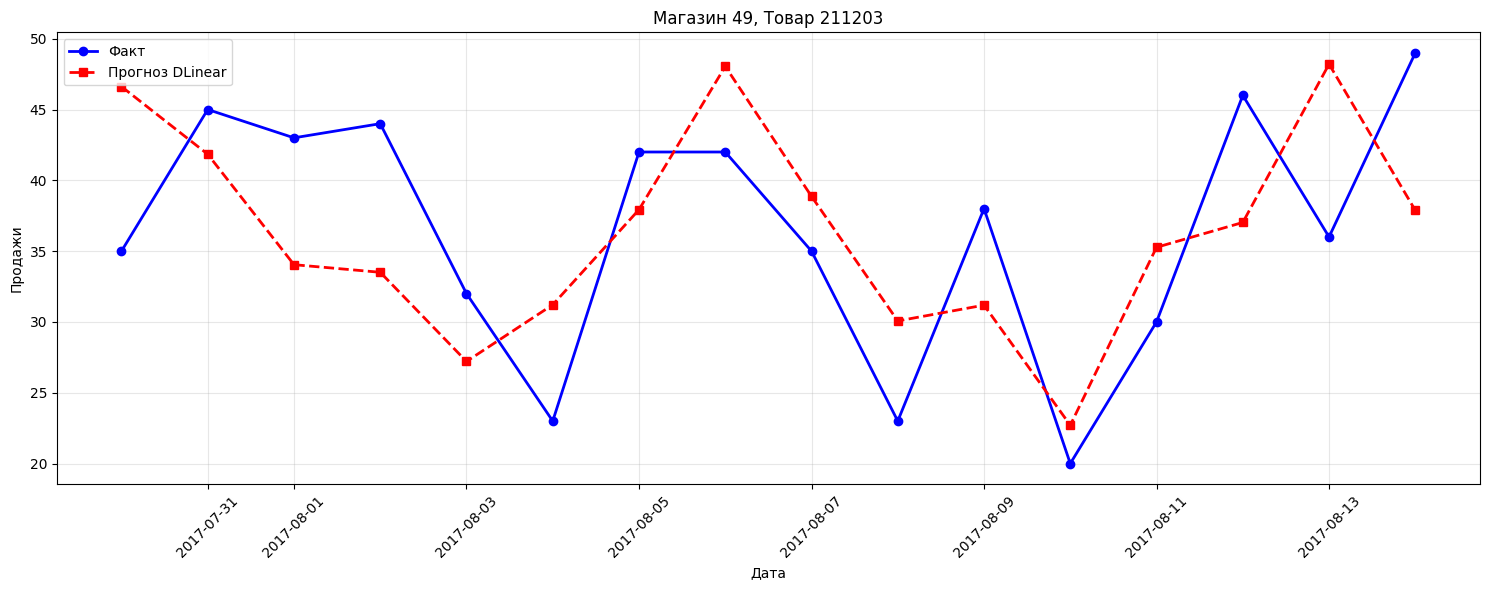

In [10]:
example_store, example_item = sample_pairs[10]
example_data = val_with_pred[
    (val_with_pred['store_nbr'] == example_store) & 
    (val_with_pred['item_nbr'] == example_item)
].sort_values('date')

if len(example_data) > 0:
    plt.figure(figsize=(15, 6))
    plt.plot(example_data['date'], example_data['unit_sales'], 'b-', label='Факт', linewidth=2, marker='o')
    plt.plot(example_data['date'], example_data['predicted'], 'r--', label='Прогноз DLinear', linewidth=2, marker='s')
    plt.title(f'Магазин {example_store}, Товар {example_item}')
    plt.xlabel('Дата')
    plt.ylabel('Продажи')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Получился практически эталонный путь - каждое последующее решение лучше предыдущего!)

Скор: **0.481897**.

Модель хорошо попадает в форму графика, что подтверждает и хороший скор.

Кроме того, хочу отметить и ещё одно наблюдение - отрабатывает DLinear ощутимо быстрее, не смотря даже на то, что torch у меня не хочет из коробки на GPU вставать. И не смотря на это, DLinear у меня обучились за минуту, а CatBoost'ы на GPU за 10 минут. Все же простота по итогу победила, получается :D